In [52]:

import pandas as pd
import numpy as np

In [53]:
# data import done
df = pd.read_csv('laptop_performance_degradation.csv')

In [54]:
# check if imported or not
print("First few rows:")
df.head()

First few rows:


,RAM_GB,Storage_SSD,CPU_GHz,Daily_Usage_hr,Background_Apps,Degradation_Percent
0,16.0,1.0,2.06,9.0,6.0,31.192888
1,4.0,1.0,3.55,7.0,14.0,38.905102
2,16.0,0.0,2.36,6.0,18.0,40.000000
3,16.0,1.0,2.37,6.0,12.0,26.071461
4,4.0,1.0,1.58,7.0,11.0,NaN


In [55]:
# see any MissinG VALues
print("Missing values in each column:")
df.isnull().sum()

Missing values in each column:


RAM_GB                 10
Storage_SSD            10
CPU_GHz                10
Daily_Usage_hr         10
Background_Apps        10
Degradation_Percent    10
dtype: int64

In [56]:
# missing values -> mean add kardo
df_filled = df.fillna(df.mean())

In [57]:
# do check for missing again
print("After cleaning - missing values:")
df_filled.isnull().sum()

After cleaning - missing values:


RAM_GB                 0
Storage_SSD            0
CPU_GHz                0
Daily_Usage_hr         0
Background_Apps        0
Degradation_Percent    0
dtype: int64

In [58]:
# graph adding 
import matplotlib.pyplot as plt
import seaborn as sns

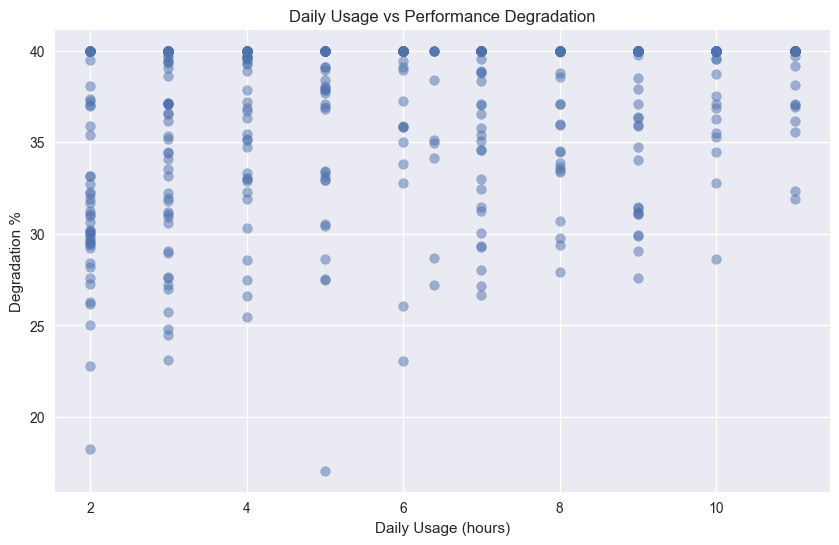

In [59]:
# ploting the graph
plt.figure(figsize=(10, 6))
plt.scatter(df_filled['Daily_Usage_hr'], df_filled['Degradation_Percent'], alpha=0.5)
plt.title('Daily Usage vs Performance Degradation')
plt.xlabel('Daily Usage (hours)')
plt.ylabel('Degradation %')
plt.show()

In [60]:
# ml liberary import
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [61]:
# data dividing for training 
X = df_filled[['RAM_GB', 'Storage_SSD', 'CPU_GHz', 'Daily_Usage_hr', 'Background_Apps']]
y = df_filled['Degradation_Percent']

In [62]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Training set: (400, 5)
Testing set: (100, 5)


In [63]:
# importing different models 
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

In [64]:
# adding all models in ONE Dictionary
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Support Vector': SVR(),
    'K-Neighbors': KNeighborsRegressor()
}

In [65]:
# Time to train all our models
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    
    results[name] = {'model': model, 'mae': mae, 'r2': r2}
    print(f"{name} - MAE: {mae:.2f}, R²: {r2:.4f}")
    print("---")

Training Linear Regression...
Linear Regression - MAE: 2.09, R²: 0.6527
---
Training Random Forest...


Random Forest - MAE: 1.35, R²: 0.7682
---
Training Decision Tree...
Decision Tree - MAE: 1.63, R²: 0.6022
---
Training Support Vector...
Support Vector - MAE: 2.31, R²: 0.3195
---
Training K-Neighbors...
K-Neighbors - MAE: 2.50, R²: 0.3281
---


In [66]:
# ch3cking which model is best 
best_model_name = min(results, key=lambda x: results[x]['mae'])
best_score = results[best_model_name]['mae']

print(f" The best model is {best_model_name} with MAE: {best_score:.2f}")

 The best model is Random Forest with MAE: 1.35


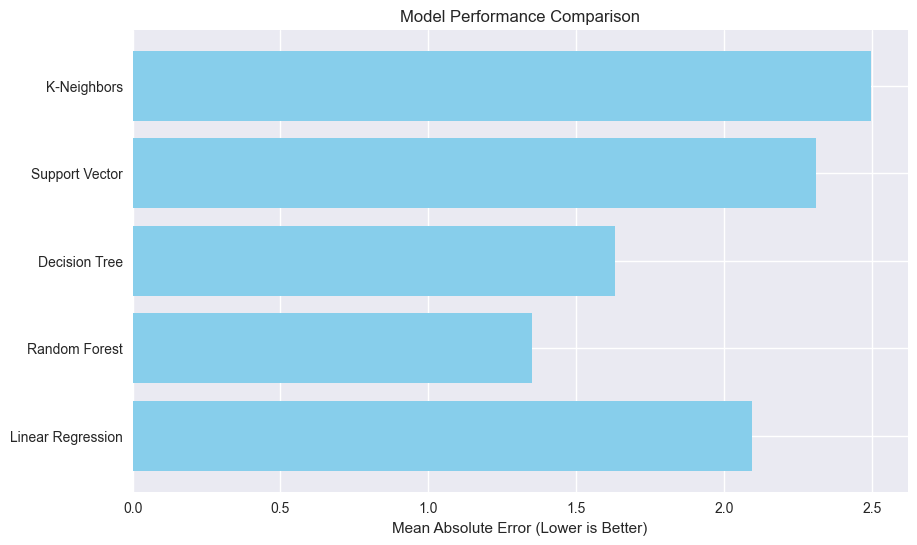

In [67]:
# Let's visualize the results
model_names = list(results.keys())
mae_scores = [results[name]['mae'] for name in model_names]

plt.figure(figsize=(10, 6))
plt.barh(model_names, mae_scores, color='skyblue')
plt.xlabel('Mean Absolute Error (Lower is Better)')
plt.title('Model Performance Comparison')
plt.show()

In [68]:
# Now let's use our best model to make predictions
best_model = results[best_model_name]['model']

# Test on some example laptops
example_laptops = [
    [8, 1, 2.5, 6, 8],   # Medium laptop
    [16, 1, 3.5, 2, 5],  # High-end laptop
    [4, 0, 1.8, 10, 15]  # Low-end laptop
]

print("📱 Performance Predictions:")
for i, laptop in enumerate(example_laptops):
    prediction = best_model.predict([laptop])[0]
    print(f"Laptop {i+1}: {prediction:.1f}% degradation")

📱 Performance Predictions:
Laptop 1: 32.4% degradation
Laptop 2: 25.8% degradation
Laptop 3: 40.0% degradation


In [69]:
# Finally, let's save our best model for later use
import joblib

joblib.dump(best_model, 'best_laptop_predictor.pkl')
print(" Model saved as 'best_laptop_predictor.pkl'")

 Model saved as 'best_laptop_predictor.pkl'
